In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle("../data/01_df_data_all.pkl")

# dependent variables

## action taken

In [3]:
df.groupby('action_taken').size()

action_taken
Approved not accepted                  2493
Denied                                15898
Incomplete                            14306
Originated                            94243
Preapproval approved not accepted      1082
Preapproval denied                     2746
Purchased                            212751
Withdrawn                             25475
dtype: int64

In [4]:
df['reg_uw'] = (df['action_taken']).isin(['Approved not accepted','Originated','Denied']).astype(int)

In [5]:
df.groupby(['reg_uw','action_taken']).size()

reg_uw  action_taken                     
0       Incomplete                            14306
        Preapproval approved not accepted      1082
        Preapproval denied                     2746
        Purchased                            212751
        Withdrawn                             25475
1       Approved not accepted                  2493
        Denied                                15898
        Originated                            94243
dtype: int64

In [6]:
df['denied'] = df['action_taken'].apply(lambda x: 1 if x == 'Denied' else 0)

In [7]:
df.groupby('denied').size()

denied
0    353096
1     15898
dtype: int64

## interest rate

<Axes: >

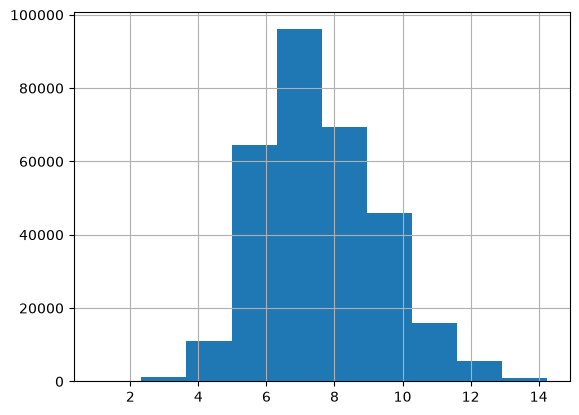

In [8]:
df.interest_rate.hist()

In [9]:
df.groupby('action_taken').agg(
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,mi_rate,mu_rate,mx_rate
action_taken,,,
Approved not accepted,1.875,6.633895,10.240
Denied,NaN,NaN,NaN
Incomplete,NaN,NaN,NaN
Originated,1.000,6.483556,12.740
Preapproval approved not accepted,5.250,6.573542,8.625
Preapproval denied,NaN,NaN,NaN
Purchased,1.000,8.062459,14.250
Withdrawn,NaN,NaN,NaN


In [10]:
df['reg_price'] = (df['action_taken']).isin(['Approved not accepted','Originated']).astype(int)

# Segments

## Loan Type

In [11]:
df.groupby('loan_type').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
loan_type,,,,,,
Conventional,354047,14420,0.040729,1.000,7.626819,14.250
FHA insured,11679,1280,0.109598,2.250,5.919252,9.500
USDA RHS FSA guaranteed,293,2,0.006826,2.625,4.402509,8.500
VA guaranteed,2975,196,0.065882,2.250,5.901986,8.375


In [12]:
df = df[df['loan_type'].isin(['Conventional','FHA insured','VA guaranteed'])]

## Loan Purpose

In [13]:
df.groupby('loan_purpose').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
loan_purpose,,,,,,
Cash out refinance,157845,3395,0.021508,2.000,8.569662,14.25
Home improvement,7983,1447,0.181260,4.375,7.777903,10.24
Home purchase,137664,7338,0.053304,1.000,6.489491,13.86
Not applicable,4897,0,0.000000,1.000,5.806357,14.00
Other,13276,2092,0.157578,3.375,7.383253,12.74
Refinance,47036,1624,0.034527,1.750,6.913556,13.99


In [14]:
df = df[df['loan_purpose'].isin(['Cash out refinance','Home improvement','Home purchase','Refinance'])]

## single vs joint

Bin the age reported into one of the ranged provided. Report 8888 if Age is NA or 9999 if No-Co-Applicant




In [15]:
df.groupby("co_applicant_age").size()

co_applicant_age
25-34     18927
35-44     19762
45-54     12740
55-64     11063
65-74      7528
8888     178421
9999      97219
<25        1828
>74        3040
dtype: int64

In [16]:
df['co_applicant_age'].info()

<class 'pandas.Series'>
Index: 350528 entries, 0 to 368993
Series name: co_applicant_age
Non-Null Count   Dtype
--------------   -----
350528 non-null  str  
dtypes: str(1)
memory usage: 5.3 MB


In [17]:
df["joint_application"] = (
    (
    df["co_applicant_age"]
    .astype(str)
    .str.strip()
) != '9999'
).astype(int)

In [18]:
df["joint_application"].value_counts()

joint_application
1    253309
0     97219
Name: count, dtype: int64

In [19]:
df = df[df['joint_application'] == 0]

## save segments

In [20]:
df.to_pickle('../data/02_df_data.pkl')

# Protected Basis Tests 

## Race

In [21]:


df.groupby('applicant_race_1').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
applicant_race_1,,,,,,
American Indian Alaska Native,801,90,0.112360,2.750,6.391158,9.490
Asian,9559,765,0.080029,2.625,6.133085,9.740
Asian Indian,1725,140,0.081159,3.875,6.003797,9.240
Black African American,9350,1232,0.131765,2.500,6.472204,10.240
Chinese,483,52,0.107660,3.990,6.114193,9.240
Filipino,225,28,0.124444,4.500,6.561306,9.365
Guamanian Chamorro,10,1,0.100000,4.990,6.092500,6.625
Info not provided,8805,733,0.083248,2.687,6.373769,10.240
Japanese,59,13,0.220339,3.000,6.420200,8.740


In [22]:
df = df[df['applicant_race_1'].isin(['Asian','Black African American','White'])]

## Gender

In [23]:

df.groupby('applicant_sex').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
applicant_sex,,,,,,
Both male female,28,3,0.107143,5.750,6.716875,8.99
Female,30973,2841,0.091725,1.000,6.428856,10.24
Info not provided,121,12,0.099174,3.125,6.286585,8.24
Male,48609,4518,0.092946,2.375,6.423524,10.24


## Age

In [24]:

df.groupby('applicant_age_above_62').agg(
    count=('denied','size'),
    event_count=('denied','sum'),
    event_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,event_count,event_rate,mi_rate,mu_rate,mx_rate
applicant_age_above_62,,,,,,
No,65100,5667,0.087051,1.000,6.402641,10.24
Yes,14631,1707,0.116670,2.375,6.535821,10.24


# referenece groups

In [25]:
ref_groups = {
    'applicant_race_1': 'White',
    'applicant_sex':'Male',
    'applicant_age_above_62': 'No'
}

In [26]:
import pickle

# Save the dictionary
with open("../data/02_dic_ref_groups.pkl", "wb") as file:
    pickle.dump(ref_groups, file)

# Load the dictionary
# with open("data.pkl", "rb") as file:
#     loaded_data = pickle.load(file)

# Test Criteria

In [27]:
crit_event = 100
crit_count = 500

In [28]:


def test_crit(df, pb, crit_event, crit_count):
    tmp = df.groupby(['loan_type','loan_purpose', pb]).agg(
        applied=('denied','size'),
        event_count=('denied','sum'),
        event_rate=('denied','mean'),
        mi_rate=('interest_rate','min'),
        mu_rate=('interest_rate','mean'),
        mx_rate=('interest_rate','max')
    ).reset_index()
    
    
    tmp['crit event'] = tmp['event_count'].apply(lambda x: True if x >= crit_event else False)
    tmp['crit count'] = tmp['applied'].apply(lambda x: True if x >= crit_count else False)

    
    tmp = tmp[(tmp['crit event'] == True) & (tmp['crit count'] == True)]


    tmp = tmp[
        tmp.groupby(["loan_type", "loan_purpose"])["loan_type"]
          .transform("size")
          .gt(1)
    ]
    

    return tmp

## Race

In [29]:
seg_race = test_crit(df, 'applicant_race_1', 100, 500)
seg_race

,loan_type,loan_purpose,applicant_race_1,applied,event_count,event_rate,mi_rate,mu_rate,mx_rate,crit event,crit count
1,Conventional,Cash out refinance,Black African American,1761,257,0.145940,4.490,6.737013,9.740,True,True
2,Conventional,Cash out refinance,White,9223,1274,0.138133,2.875,6.765602,10.240,True,True
4,Conventional,Home improvement,Black African American,541,128,0.236599,4.750,7.659269,10.240,True,True
5,Conventional,Home improvement,White,3644,669,0.183589,4.625,7.822651,10.240,True,True
6,Conventional,Home purchase,Asian,6913,458,0.066252,2.625,6.136274,8.990,True,True
7,Conventional,Home purchase,Black African American,4818,502,0.104193,2.500,6.380016,9.240,True,True
8,Conventional,Home purchase,White,36101,2336,0.064707,1.000,6.375974,9.490,True,True
9,Conventional,Refinance,Asian,1701,137,0.080541,3.750,5.902198,8.030,True,True
11,Conventional,Refinance,White,7497,559,0.074563,4.250,6.179631,8.375,True,True
18,FHA insured,Home purchase,Black African American,884,125,0.141403,4.125,6.339181,7.750,True,True


In [30]:
seg_race.to_pickle('../data/02_df_seg_race')

## Gender

In [31]:
seg_gen = test_crit(df, 'applicant_sex', 100, 500)
seg_gen

,loan_type,loan_purpose,applicant_sex,applied,event_count,event_rate,mi_rate,mu_rate,mx_rate,crit event,crit count
1,Conventional,Cash out refinance,Female,5053,634,0.125470,4.490,6.705315,9.740,True,True
3,Conventional,Cash out refinance,Male,6446,990,0.153584,2.875,6.804652,10.240,True,True
5,Conventional,Home improvement,Female,1707,303,0.177504,4.875,7.679076,10.240,True,True
7,Conventional,Home improvement,Male,2683,540,0.201267,4.625,7.864990,10.240,True,True
9,Conventional,Home purchase,Female,18239,1275,0.069905,1.000,6.344006,9.365,True,True
11,Conventional,Home purchase,Male,29493,2013,0.068253,2.375,6.344405,9.490,True,True
13,Conventional,Refinance,Female,3608,277,0.076774,4.250,6.170149,8.375,True,True
15,Conventional,Refinance,Male,6278,500,0.079643,3.750,6.116714,8.125,True,True
17,FHA insured,Cash out refinance,Female,590,153,0.259322,4.750,6.183658,7.750,True,True
18,FHA insured,Cash out refinance,Male,644,143,0.222050,4.500,6.146054,7.250,True,True


In [32]:
seg_gen.to_pickle('../data/02_df_seg_gen')

## Age

In [33]:
seg_age = test_crit(df, 'applicant_age_above_62', 100, 500)
seg_age

,loan_type,loan_purpose,applicant_age_above_62,applied,event_count,event_rate,mi_rate,mu_rate,mx_rate,crit event,crit count
0,Conventional,Cash out refinance,No,6982,991,0.141936,2.875,6.797045,10.240,True,True
1,Conventional,Cash out refinance,Yes,4529,636,0.140428,4.250,6.699005,10.240,True,True
2,Conventional,Home improvement,No,2666,550,0.206302,4.625,7.983977,10.240,True,True
3,Conventional,Home improvement,Yes,1730,295,0.170520,5.125,7.447902,9.740,True,True
4,Conventional,Home purchase,No,42074,2828,0.067215,1.000,6.341432,9.490,True,True
5,Conventional,Home purchase,Yes,5758,468,0.081278,2.375,6.363793,9.240,True,True
6,Conventional,Refinance,No,8142,619,0.076026,3.750,6.117662,8.375,True,True
7,Conventional,Refinance,Yes,1765,160,0.090652,4.750,6.231279,7.750,True,True


In [34]:
seg_age.to_pickle('../data/02_df_seg_age')